In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
import openai
import base64
import io
import os
from dotenv import load_dotenv

#load_dotenv()
#openai.my_api_key = os.getenv('masukin kunci api')

In [12]:
# Open model from folder
with open("model.pkl", 'rb') as file_1:
  model = pickle.load(file_1)

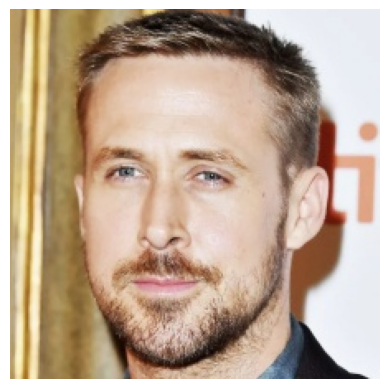

In [24]:
# Pick inference image and illustrate (Can be replaced with another image)
test_image = mpimg.imread('TE__ovale__ovale t1.jpg')
plt.imshow(test_image)
plt.axis("off")
plt.show()

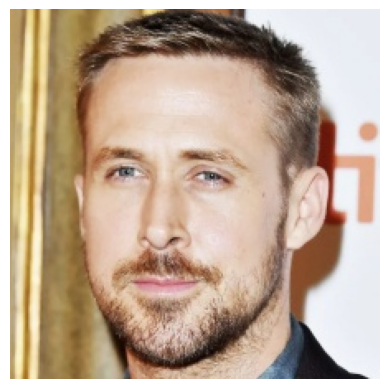

In [14]:
target_size = (224, 224)

def resize(image):
    image = cv2.resize(image, target_size)
    return image
test_image = resize(test_image)
plt.imshow(test_image)
plt.axis("off")
plt.show()

test_image = test_image / 255.

In [15]:
# Predict an image

y_pred = model.predict(np.expand_dims(test_image, 0))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step


array([[8.8441974e-01, 1.1461645e-01, 9.3755062e-04, 2.6178473e-05]],
      dtype=float32)

In [16]:
# Probability for each class
class_names = class_names = ["ovale", "rectangular", "round", "square"]
y_pred_df = pd.DataFrame(y_pred, columns=class_names)
y_pred_df

,ovale,rectangular,round,square
0,0.88442,0.114616,0.000938,0.000026


In [17]:
# Get class prediction

y_pred_class = np.argmax(y_pred[0])
y_pred_class_name = class_names[np.argmax(y_pred[0])]

print('Prediction - Class       : ', y_pred_class)
print('Prediction - Class Name  : ', y_pred_class_name)

Prediction - Class       :  0
Prediction - Class Name  :  ovale


In [18]:
#Source : https://clippersbarbershop-tx.com/mens-haircuts-by-face-shape/

hairstyle = None

if y_pred_class_name == "square":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Textured crop, quiff, high fade, undercut, side part, pompadour")
    hairstyle = "Textured crop"

if y_pred_class_name == "ovale":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour")
    hairstyle = "Pompadour"

if y_pred_class_name == "round":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: High fade with textured top, pompadour, quiff, side part, faux hawk")
    hairstyle = "High fade with textured top"

if y_pred_class_name == "rectangular":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Layered or medium-length styles, side part with texture, shoulder-length/shaggy styles")
    hairstyle = "Layered or medium-length styles"


Face Shape: ovale
Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour


Loading...


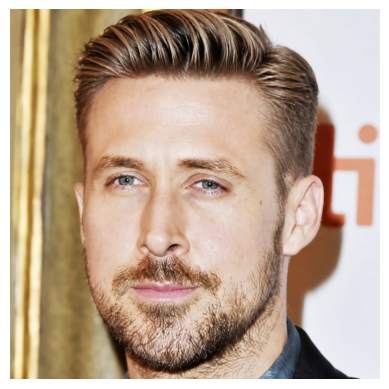

In [ ]:
client = openai.OpenAI(api_key=openai.my_api_key )

prompt = f"if there is a face of a man in the photo, change his hairstyle into {hairstyle}, if not send response : no face detected and dont generate any picture"

img_uint8 = (test_image).astype(np.uint8)
img_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

base64_image1 = base64.b64encode(cv2.imencode(".png", img_uint8)[1]).decode("utf-8")

print("Loading...")
response = client.responses.create(
    model="gpt-5.6",
    input=[
        {"role": "user",
            "content": [
                {"type": "input_text", "text": prompt},
                {
                    "type": "input_image",
                    "image_url": f"data:image/png;base64,{base64_image1}",
                },
            ],}],
    tools=[{"type": "image_generation"}],)

image_generation_calls = [
    output for output in response.output if output.type == "image_generation_call"
]

image_data = [output.result for output in image_generation_calls]

if image_data:
    image_bytes = base64.b64decode(image_data[0])
    img = mpimg.imread(io.BytesIO(image_bytes), format="png")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

else:
    print(response.output_text)